# **Libraries**

In [1]:
import numpy as np 
import pandas as pd
import os
import re
import html
import string
import warnings
warnings.filterwarnings('ignore')
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from gensim.models import Word2Vec
from nltk.stem import PorterStemmer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import torch
from sklearn.decomposition import PCA


In [2]:
path = "/kaggle/input/aljazeera-news-dataset/"

# List of CSV files to be merged
files = ["tech.csv", "economy.csv", "df.csv"]

# Read and merge them into one dataframe
data_news = pd.concat([pd.read_csv(os.path.join(path, f)) for f in files],
                      ignore_index=True)

# **Data exploration**

In [3]:
data_news.head()

,category,title,article_content
0,Science & Technology,Maria Telkes: Why Google honours her today,Telkes was an innovative scientist recognised ...
1,Science & Technology,US extends export bans on three firms over ill...,Firms sent technical drawings blueprints from ...
2,Science & Technology,Shrinking natural habitats push wildlife and c...,Cities like Detroit in the US take efforts to ...
3,Science & Technology,Data shows drug slowing Alzheimer’s but doubts...,Study finds lecanemab modestly slowed disease’...
4,Science & Technology,Racing to develop Africa’s next-gen vaccines b...,How scientists in South Africa and across the ...


In [4]:
data_news.shape

(4439, 3)

Our dataset contains the following columns:

In [5]:
data_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   category         4439 non-null   object
 1   title            4439 non-null   object
 2   article_content  4439 non-null   object
dtypes: object(3)
memory usage: 104.2+ KB


In [6]:
print("\n--- Duplicate rows ---")
print(data_news.duplicated().sum())


--- Duplicate rows ---
1


In [7]:
#show the duplicated row
duplicate_rows = data_news[data_news.duplicated(keep=False)]
print(duplicate_rows)


     category                                              title  \
3600   Sports  FIFA World Cup 1938: Italy defend title before...   
3601   Sports  FIFA World Cup 1938: Italy defend title before...   

                                        article_content  
3600  The 1938 WC was held under the shadow of Spani...  
3601  The 1938 WC was held under the shadow of Spani...  


In [8]:
#drop one 
data_news = data_news.drop_duplicates(keep='first')

<Axes: xlabel='category'>

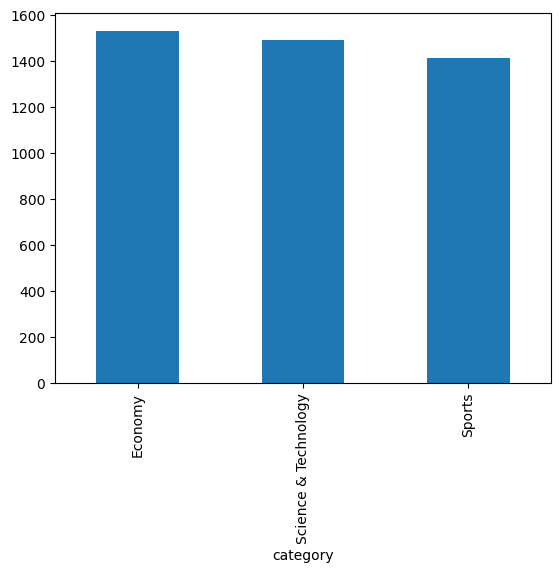

In [9]:
data_news['category'].value_counts().plot(kind='bar')


This dataset covers 3 categories : economy , science & tech and sports

In [10]:
category_counts = data_news['category'].value_counts()
print(category_counts)

category
Economy                 1532
Science & Technology    1493
Sports                  1413
Name: count, dtype: int64


In [11]:
data_news['article_length_words'] = data_news['article_content'].astype(str).apply(lambda x: len(x.split()))

# Check stats
print("\n--- article content stats ---")
print(data_news['article_length_words'].describe())



--- article content stats ---
count    4438.000000
mean      590.248085
std       385.625675
min        16.000000
25%       358.250000
50%       503.500000
75%       709.000000
max      4738.000000
Name: article_length_words, dtype: float64


The mean length of the article content is 503 words

In [12]:
data_news['title_length'] = data_news['title'].apply(len)
print("\n--- title stats ---")
print(data_news['title_length'].describe())


--- title stats ---
count    4438.00000
mean       58.21699
std         7.05243
min        13.00000
25%        55.00000
50%        60.00000
75%        63.00000
max        68.00000
Name: title_length, dtype: float64


The mean length of title is 60 words

# **Data preprocessing**

We will be using the spacy because it’s fast, accurate, all-in-one, and easy to use, making classic NLP tasks like tokenization,stemming, lemmatization, POS tagging, NER, and feature extraction much simpler

In [13]:
#first we'll load spacy and its language model which is the small english one (since it is fast)
nlp = spacy.load("en_core_web_sm")

In [14]:
def clean_text(text):
    """Clean text for news articles, keeping readability while removing noise like URLs, emails, emojis, etc."""
    if not text or not isinstance(text, str):
        return ""
    
    # Decode HTML entities
    text = html.unescape(text)
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Remove URLs (improved pattern)
    text = re.sub(r'https?://[^\s]+|www\.[^\s]+|t\.co/\S+', ' ', text)
    
    # Remove social media artifacts
    text = re.sub(r'pic\.twitter\.com/\S+', ' ', text)
    text = re.sub(r'— .*?@\S+.*?(?:\s+\w+\s+\d{1,2},\s+\d{4})?', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', ' ', text)
    
    # Remove hashtags and mentions
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    
    # Remove arrows and special symbols
    text = re.sub(r'[→←↑↓➜]', ' ', text)
    
    # Remove promotional phrases and everything following until sentence boundary
    promo_phrases = [
        "ADVERTISEMENT","SPONSORED","SUBSCRIBE NOW","CLICK HERE",
        "READ MORE","LEARN MORE","SIGN UP","JOIN NOW","FOLLOW US",
        "WATCH NOW","SEE MORE","CONTINUE READING","NEXT ARTICLE",
        "SCROLL DOWN","BACK TO TOP","CONTACT US","PRIVACY POLICY",
        "TERMS OF SERVICE","ALL RIGHTS RESERVED"
    ]
    for phrase in promo_phrases:
        text = re.sub(r'\b' + re.escape(phrase) + r'\b[^.!?]*?(?:[.!?]|$)', ' ', text, flags=re.IGNORECASE)
    
    # Remove emojis (comprehensive pattern)
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002700-\U000027BF"  # dingbats
                               u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                               u"\U00002600-\U000026FF"  # Miscellaneous Symbols
                               u"\U0001F170-\U0001F251"  # Enclosed characters
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(' ', text)
    
    # Handle dashes - keep word-internal hyphens, remove standalone dashes
    text = re.sub(r'\s+–\s+|\s+—\s+', ' ', text)  # remove spaced long dashes
    text = re.sub(r'^–\s*|^—\s*', '', text)       # remove leading dashes
    
    # Normalize quotes and apostrophes
    text = re.sub(r'["""«»]', '"', text)
    text = re.sub(r"['']", "'", text)
    
    # Fix spacing issues around punctuation
    text = re.sub(r'\s+([,.!?;:])', r'\1', text)
    text = re.sub(r'([.!?])\s*([A-Z])', r'\1 \2', text)
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

# Example usage with before/after
sample_text = data_news['article_content'].iloc[0]

print("---- BEFORE ----")
print(sample_text)
print("\n---- AFTER ----")
print(clean_text(sample_text))


---- BEFORE ----
Telkes was an innovative scientist recognised for her contributions to the solar energy technologies.Hungarian-American scientist Maria Telkes is known for her contributions to solar energy technologies.Telkes, who died in 1995, invented the solar distiller as well as the first solar-powered heating system designed for residences.On Monday, Google changed its logo in 12 countries to a doodle, or illustration, in her honour.This is her story:Rays and shine! Today’s #GoogleDoodle celebrates the life of Dr. Mária Telkes, a pioneer in solar energy who's known as The Sun Queen 👑Learn more about her legacy here → https://t.co/pGuuVif9Ra pic.twitter.com/Ks0rgPXIcA— Google Doodles (@GoogleDoodles) December 12, 2022

---- AFTER ----
Telkes was an innovative scientist recognised for her contributions to the solar energy technologies. Hungarian-American scientist Maria Telkes is known for her contributions to solar energy technologies. Telkes, who died in 1995, invented the solar

We can say that overall this cleaning is robust , we can proceed with cleaning the article content 

In [15]:
data_news['article_content_cleaned'] = data_news['article_content'].apply(clean_text)
print(f"Cleaned {len(data_news)} articles successfully!")

Cleaned 4438 articles successfully!


# **CLASSIC NLP PIPELINE**

# **Tokenization using spacy**

In [16]:
tokenizer = nlp.tokenizer
docs = [nlp.tokenizer(text) for text in data_news['article_content_cleaned']]

Tokens display of the first 2 articles

In [17]:
# Extract tokens for each article
data_news['tokens'] = [[token.text for token in doc] for doc in docs]

for i, tokens in enumerate(data_news['tokens'].head(2)):
    print(f"Article {i} tokens: {tokens}\n")


Article 0 tokens: ['Telkes', 'was', 'an', 'innovative', 'scientist', 'recognised', 'for', 'her', 'contributions', 'to', 'the', 'solar', 'energy', 'technologies', '.', 'Hungarian', '-', 'American', 'scientist', 'Maria', 'Telkes', 'is', 'known', 'for', 'her', 'contributions', 'to', 'solar', 'energy', 'technologies', '.', 'Telkes', ',', 'who', 'died', 'in', '1995', ',', 'invented', 'the', 'solar', 'distiller', 'as', 'well', 'as', 'the', 'first', 'solar', '-', 'powered', 'heating', 'system', 'designed', 'for', 'residences', '.', 'On', 'Monday', ',', 'Google', 'changed', 'its', 'logo', 'in', '12', 'countries', 'to', 'a', 'doodle', ',', 'or', 'illustration', ',', 'in', 'her', 'honour', '.', 'This', 'is', 'her', 'story', ':', 'Rays', 'and', 'shine', '!', 'Today', '’s', 'celebrates', 'the', 'life', 'of', 'Dr.', 'Mária', 'Telkes', ',', 'a', 'pioneer', 'in', 'solar', 'energy', 'who', "'s", 'known', 'as', 'The', 'Sun', 'Queen']

Article 1 tokens: ['Firms', 'sent', 'technical', 'drawings', 'bluepr

Now we proceed with punctuation and stop word removal 

In [18]:
print(STOP_WORDS)

{'neither', 'name', 'none', 'too', 'everything', 'wherever', 'thereupon', 'each', 'through', 'wherein', 'must', 'same', '‘s', 'whatever', 'nobody', 'thence', 'formerly', 'hereby', 'should', 'upon', 'your', 'down', 'six', 'so', 'except', 'nor', 'rather', 'then', 'call', '’m', 'i', 'how', 'please', 'three', 'about', 'the', 'very', 'whereby', 'move', 'every', 'other', 'empty', 'say', 'somehow', 'made', '’re', 'could', 'always', 'any', 'cannot', 'ours', 'against', 'still', 'others', 'hence', 'with', 'below', 'fifty', 'anywhere', 'thereafter', 'herself', 'once', 'whenever', 'see', 'whereafter', 'not', 'though', 'up', 'most', 'yourselves', 'own', 'because', '’s', 'nine', 'among', 'already', 'before', 'above', 'eight', 'been', 'everywhere', 'serious', 'me', 'such', 'these', 'anyone', 'almost', 'indeed', 'a', 'much', 'from', 'next', 'first', 'alone', 'someone', 'together', 'would', 'became', 'bottom', 'done', 'amount', 'go', 'often', 'until', 'had', 'sixty', "'m", 'eleven', 'seemed', 'whether'

In [19]:
# Remove stopwords
data_news['tokens_no_stop'] = data_news['tokens'].apply(lambda tokens: [token for token in tokens if token.lower() not in STOP_WORDS])

# Remove punctuation and lowercase (for Word2Vec preparation)
data_news['tokens_clean'] = data_news['tokens_no_stop'].apply(
    lambda tokens: [token.lower() for token in tokens if any(c.isalpha() for c in token)]
)

# Show first 5 articles with tokens after stop word removal and their counts
for i, row in data_news.head(5).iterrows():
    print(f"Article {i} tokens (no stop words): {row['tokens_no_stop']}")
    print(f"Number of tokens: {len(row['tokens_no_stop'])}")
    print(f"Article {i} tokens (cleaned): {row['tokens_clean']}")
    print(f"Number of clean tokens: {len(row['tokens_clean'])}\n")

# Count the number of tokens after stop word removal and cleaning
data_news['num_tokens_no_stop'] = data_news['tokens_no_stop'].apply(len)
data_news['num_tokens_clean'] = data_news['tokens_clean'].apply(len)

Article 0 tokens (no stop words): ['Telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', '.', 'Hungarian', '-', 'American', 'scientist', 'Maria', 'Telkes', 'known', 'contributions', 'solar', 'energy', 'technologies', '.', 'Telkes', ',', 'died', '1995', ',', 'invented', 'solar', 'distiller', 'solar', '-', 'powered', 'heating', 'system', 'designed', 'residences', '.', 'Monday', ',', 'Google', 'changed', 'logo', '12', 'countries', 'doodle', ',', 'illustration', ',', 'honour', '.', 'story', ':', 'Rays', 'shine', '!', 'Today', 'celebrates', 'life', 'Dr.', 'Mária', 'Telkes', ',', 'pioneer', 'solar', 'energy', 'known', 'Sun', 'Queen']
Number of tokens: 68
Article 0 tokens (cleaned): ['telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', 'hungarian', 'american', 'scientist', 'maria', 'telkes', 'known', 'contributions', 'solar', 'energy', 'technologies', 'telkes', 'died', 'invented', 'solar', 'dist

In [20]:
print(data_news['num_tokens_clean'].describe())

count    4438.000000
mean      328.032447
std       202.224695
min         7.000000
25%       205.000000
50%       285.000000
75%       393.750000
max      2567.000000
Name: num_tokens_clean, dtype: float64


On average , we have 285 tokens per article after the stop word & punctuation removal

In [22]:
#vocab size for cleaned tokens
all_clean_tokens = [token for tokens in data_news['tokens_clean'] for token in tokens]
clean_vocab_size = len(set(all_clean_tokens))
print(f"Vocabulary size after cleaning: {clean_vocab_size:,}")

Vocabulary size after cleaning: 59,542


# **Lemmatization**

In [23]:
# Apply lemmatization to clean tokens using spaCy
#context aware lemmatization
data_news['lemmas'] = data_news['tokens_clean'].apply(
    lambda tokens: [token.lemma_.lower() for token in nlp(" ".join(tokens))
                   if any(c.isalpha() for c in token.lemma_)]
)


In [24]:
# Display lemmatization results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} LEMMATIZATION COMPARISON ===")
    
    print(f"\nOriginal clean tokens (first 15):")
    print(data_news.iloc[i]['tokens_clean'][:15])
    
    print(f"\nAfter lemmatization (first 15):")
    print(data_news.iloc[i]['lemmas'][:15])
    
    print(f"\nSide-by-side comparison (first 10):")
    for orig, lemma in zip(data_news.iloc[i]['tokens_clean'][:10], data_news.iloc[i]['lemmas'][:10]):
        if orig != lemma:  # Only show words that changed
            print(f"  {orig} → {lemma}")
    
    print(f"\n" + "="*50 + "\n")

=== ARTICLE 0 LEMMATIZATION COMPARISON ===

Original clean tokens (first 15):
['telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', 'hungarian', 'american', 'scientist', 'maria', 'telkes', 'known', 'contributions']

After lemmatization (first 15):
['telke', 'innovative', 'scientist', 'recognise', 'contribution', 'solar', 'energy', 'technology', 'hungarian', 'american', 'scientist', 'maria', 'telke', 'know', 'contribution']

Side-by-side comparison (first 10):
  telkes → telke
  recognised → recognise
  contributions → contribution
  technologies → technology


=== ARTICLE 1 LEMMATIZATION COMPARISON ===

Original clean tokens (first 15):
['firms', 'sent', 'technical', 'drawings', 'blueprints', 'customers', 'manufacturers', 'china', 'd', 'print', 'defence', 'prototypes', 'authorisation', 'department', 'commerce']

After lemmatization (first 15):
['firm', 'send', 'technical', 'drawing', 'blueprint', 'customer', 'manufacturer', 'china', 'd'

In [26]:
all_lemmas = [lemma for lemmas in data_news['lemmas'] for lemma in lemmas]
lemma_vocab_size = len(set(all_lemmas))
print(f"Vocabulary size after lemmatization: {lemma_vocab_size:,}")

Vocabulary size after lemmatization: 48,833


# **Stemming**

In [27]:
#since spacy doesnt have stemming built it we'll be using nltk's
stemmer = PorterStemmer()

data_news['stems'] = data_news['tokens_clean'].apply(
    lambda tokens: [stemmer.stem(token) for token in tokens]
)

In [28]:
# Display stemming results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} STEMMING COMPARISON ===")
    
    print(f"\nOriginal clean tokens (first 15):")
    print(data_news.iloc[i]['tokens_clean'][:15])
    
    print(f"\nAfter stemming (first 15):")
    print(data_news.iloc[i]['stems'][:15])
    
    print(f"\nSide-by-side comparison (first 10):")
    for orig, stem in zip(data_news.iloc[i]['tokens_clean'][:10], data_news.iloc[i]['stems'][:10]):
        if orig != stem:  # Only show words that changed
            print(f"  {orig} → {stem}")
    
    print(f"\n" + "="*50 + "\n")

# Check vocabulary size reduction from stemming
all_stems = [stem for stems in data_news['stems'] for stem in stems]
stem_vocab_size = len(set(all_stems))
print(f"Vocabulary size after stemming: {stem_vocab_size:,}")

=== ARTICLE 0 STEMMING COMPARISON ===

Original clean tokens (first 15):
['telkes', 'innovative', 'scientist', 'recognised', 'contributions', 'solar', 'energy', 'technologies', 'hungarian', 'american', 'scientist', 'maria', 'telkes', 'known', 'contributions']

After stemming (first 15):
['telk', 'innov', 'scientist', 'recognis', 'contribut', 'solar', 'energi', 'technolog', 'hungarian', 'american', 'scientist', 'maria', 'telk', 'known', 'contribut']

Side-by-side comparison (first 10):
  telkes → telk
  innovative → innov
  recognised → recognis
  contributions → contribut
  energy → energi
  technologies → technolog


=== ARTICLE 1 STEMMING COMPARISON ===

Original clean tokens (first 15):
['firms', 'sent', 'technical', 'drawings', 'blueprints', 'customers', 'manufacturers', 'china', 'd', 'print', 'defence', 'prototypes', 'authorisation', 'department', 'commerce']

After stemming (first 15):
['firm', 'sent', 'technic', 'draw', 'blueprint', 'custom', 'manufactur', 'china', 'd', 'print',

# **POS**

In [29]:
# POS tags for clean tokens
data_news['pos_tags'] = data_news['tokens_clean'].apply(
    lambda tokens: [(token.text, token.pos_) for token in nlp(" ".join(tokens))
                   if any(c.isalpha() for c in token.text)]
)

In [30]:
# Display POS results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} POS TAGGING ===")
    
    print(f"\nPOS Tags (first 15):")
    pos_sample = data_news.iloc[i]['pos_tags'][:15]
    for word, pos in pos_sample:
        print(f"  {word} → {pos}")
    
    print(f"\n" + "="*50 + "\n")

=== ARTICLE 0 POS TAGGING ===

POS Tags (first 15):
  telkes → NOUN
  innovative → ADJ
  scientist → NOUN
  recognised → VERB
  contributions → NOUN
  solar → ADJ
  energy → NOUN
  technologies → NOUN
  hungarian → ADJ
  american → PROPN
  scientist → PROPN
  maria → PROPN
  telkes → VERB
  known → VERB
  contributions → NOUN


=== ARTICLE 1 POS TAGGING ===

POS Tags (first 15):
  firms → NOUN
  sent → VERB
  technical → ADJ
  drawings → NOUN
  blueprints → VERB
  customers → NOUN
  manufacturers → NOUN
  china → PROPN
  d → PROPN
  print → NOUN
  defence → NOUN
  prototypes → NOUN
  authorisation → PROPN
  department → PROPN
  commerce → PROPN




# **NER**


In [31]:
# NER needs full text context, so reconstruct from clean tokens
data_news['entities'] = data_news['tokens_clean'].apply(
    lambda tokens: [(ent.text, ent.label_) for ent in nlp(" ".join(tokens)).ents]
)


In [33]:
# Display NER results for first 2 articles
for i in range(2):
    print(f"=== ARTICLE {i} NAMED ENTITIES ===")
    
    entities = data_news.iloc[i]['entities']
    if entities:
        for entity, label in entities:
            print(f"  '{entity}' → {label}")
    else:
        print("  No named entities found")
    
    print(f"\n" + "="*50 + "\n")


=== ARTICLE 0 NAMED ENTITIES ===
  'hungarian' → NORP
  'american' → NORP
  'monday' → DATE
  'today' → DATE
  'mária' → PERSON


=== ARTICLE 1 NAMED ENTITIES ===
  'china' → GPE
  'china' → GPE
  'manufacturing inc rapid' → ORG
  'llc prototype inc department commerce' → ORG
  'june' → DATE
  'china' → GPE
  'north carolina' → GPE
  'june' → DATE
  'china' → GPE
  'days' → DATE
  'june' → DATE
  'february' → DATE
  'july' → DATE
  'china' → GPE
  'december' → DATE
  'china' → GPE
  'june' → DATE
  'december' → DATE
  'thursday' → DATE
  'department commerce' → ORG
  'chinese' → NORP




# **EMBEDDING**

Now we will experiment with multiple word and sentence embedding techniques to represent our news articles and evaluate their impact on downstream tasks:

* CBOW
* Skip-gram
* BERT


In [34]:
# Prepare corpus: list of token lists (lemmatized)
corpus = data_news['lemmas'].tolist()

**CBOW**


In [35]:
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=2,       # ignore rare words
    sg=0,              # CBOW = 0, Skip-gram = 1
    workers=4,         # number of CPU threads
    epochs=15
)


In [36]:
word = 'science'
if word in model_cbow.wv:
    vector = model_cbow.wv[word]
    print(f"CBOW embedding for '{word}' (first 5 dims):", vector[:5])
else:
    print(f"'{word}' not in vocabulary")


CBOW embedding for 'science' (first 5 dims): [0.30537942 0.9354612  3.202463   1.627967   1.711757  ]


In [37]:
similar_words = model_cbow.wv.most_similar('economy', topn=5)
print("CBOW most similar to 'economy':", similar_words)


CBOW most similar to 'economy': [('economic', 0.6072059869766235), ('recession', 0.5372849106788635), ('growth', 0.5294972658157349), ('policymaker', 0.5114700198173523), ('headwind', 0.4912104904651642)]


In [38]:
similarity = model_cbow.wv.similarity('economy', 'finance')
print("Similarity between 'economy' and 'finance':", similarity)


Similarity between 'economy' and 'finance': 0.4341008


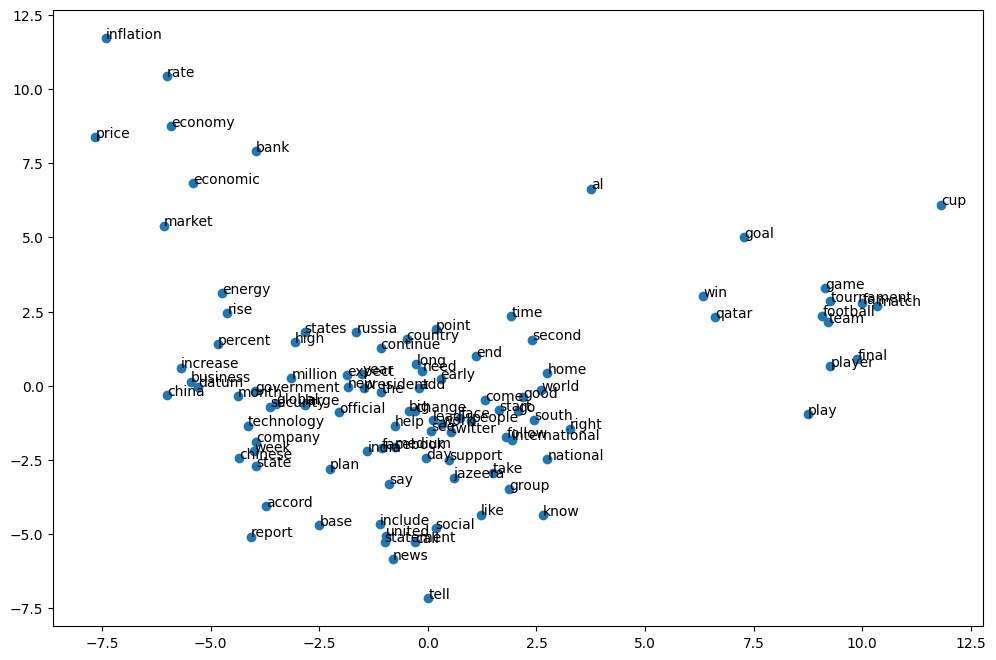

In [39]:
words = list(model_cbow.wv.index_to_key)[:100]  # first 100 words
vectors = [model_cbow.wv[w] for w in words]

pca = PCA(n_components=2)
vec_2d = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))
plt.scatter(vec_2d[:,0], vec_2d[:,1])
for i, w in enumerate(words):
    plt.annotate(w, xy=(vec_2d[i,0], vec_2d[i,1]))
plt.show()


In [41]:
# ---- Skip-gram ----
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,              # Skip-gram
    workers=4,
    epochs=15
)

In [42]:
word = 'science'
if word in model_skipgram.wv:
    vector = model_skipgram.wv[word]
    print(f"Skip-gram embedding for '{word}' (first 5 dims):", vector[:5])
else:
    print(f"'{word}' not in vocabulary")


Skip-gram embedding for 'science' (first 5 dims): [-0.02065571  0.5154347   0.29136968  0.5383041   0.8001792 ]


In [46]:
similar_words = model_skipgram.wv.most_similar('science', topn=5)
print("Skip-gram most similar to 'science':", similar_words)


Skip-gram most similar to 'science': [('mathematic', 0.7170577645301819), ('physics', 0.7011149525642395), ('magazinevidya', 0.6951378583908081), ('scientific', 0.6731888651847839), ('spectroscopy', 0.6712405681610107)]


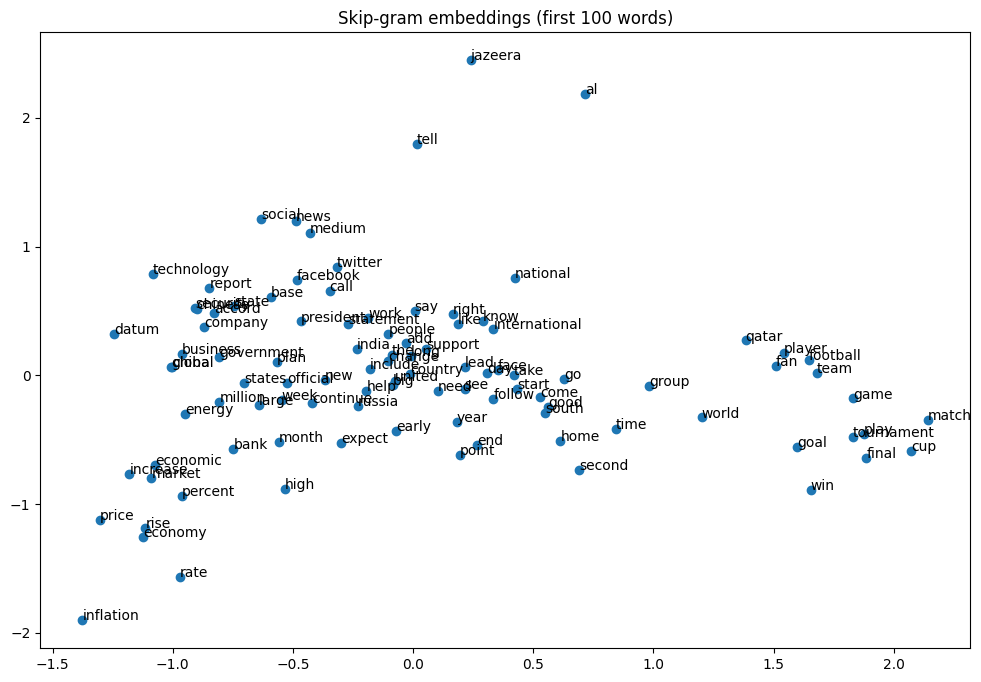

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model_skipgram.wv.index_to_key)[:100]  # first 100 words
vectors = [model_skipgram.wv[w] for w in words]

pca = PCA(n_components=2)
vec_2d = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))
plt.scatter(vec_2d[:,0], vec_2d[:,1])
for i, w in enumerate(words):
    plt.annotate(w, xy=(vec_2d[i,0], vec_2d[i,1]))
plt.title("Skip-gram embeddings (first 100 words)")
plt.show()


In [55]:
words = ['science','technology','research','economy','growth','finance','sports','football','olympics']
from itertools import combinations
for w1, w2 in combinations(words, 2):
    print(f"{w1} ~ {w2}: CBOW={model_cbow.wv.similarity(w1,w2):.2f}, Skip-gram={model_skipgram.wv.similarity(w1,w2):.2f}")


science ~ technology: CBOW=0.34, Skip-gram=0.49
science ~ research: CBOW=0.52, Skip-gram=0.47
science ~ economy: CBOW=-0.02, Skip-gram=0.23
science ~ growth: CBOW=-0.04, Skip-gram=0.21
science ~ finance: CBOW=0.17, Skip-gram=0.30
science ~ sports: CBOW=0.34, Skip-gram=0.32
science ~ football: CBOW=-0.02, Skip-gram=0.11
science ~ olympics: CBOW=0.10, Skip-gram=0.22
technology ~ research: CBOW=0.28, Skip-gram=0.47
technology ~ economy: CBOW=0.13, Skip-gram=0.34
technology ~ growth: CBOW=0.25, Skip-gram=0.35
technology ~ finance: CBOW=0.06, Skip-gram=0.35
technology ~ sports: CBOW=-0.02, Skip-gram=0.17
technology ~ football: CBOW=-0.17, Skip-gram=0.06
technology ~ olympics: CBOW=-0.04, Skip-gram=0.14
research ~ economy: CBOW=0.06, Skip-gram=0.31
research ~ growth: CBOW=0.19, Skip-gram=0.33
research ~ finance: CBOW=0.15, Skip-gram=0.38
research ~ sports: CBOW=0.24, Skip-gram=0.27
research ~ football: CBOW=-0.13, Skip-gram=0.05
research ~ olympics: CBOW=-0.03, Skip-gram=0.16
economy ~ growt

In [59]:
bert_sentences = [' '.join(tokens) for tokens in corpus]
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert_model.to(device)
bert_embeddings = bert_model.encode(bert_sentences, batch_size=32, device=device)

Batches:   0%|          | 0/139 [00:00<?, ?it/s]

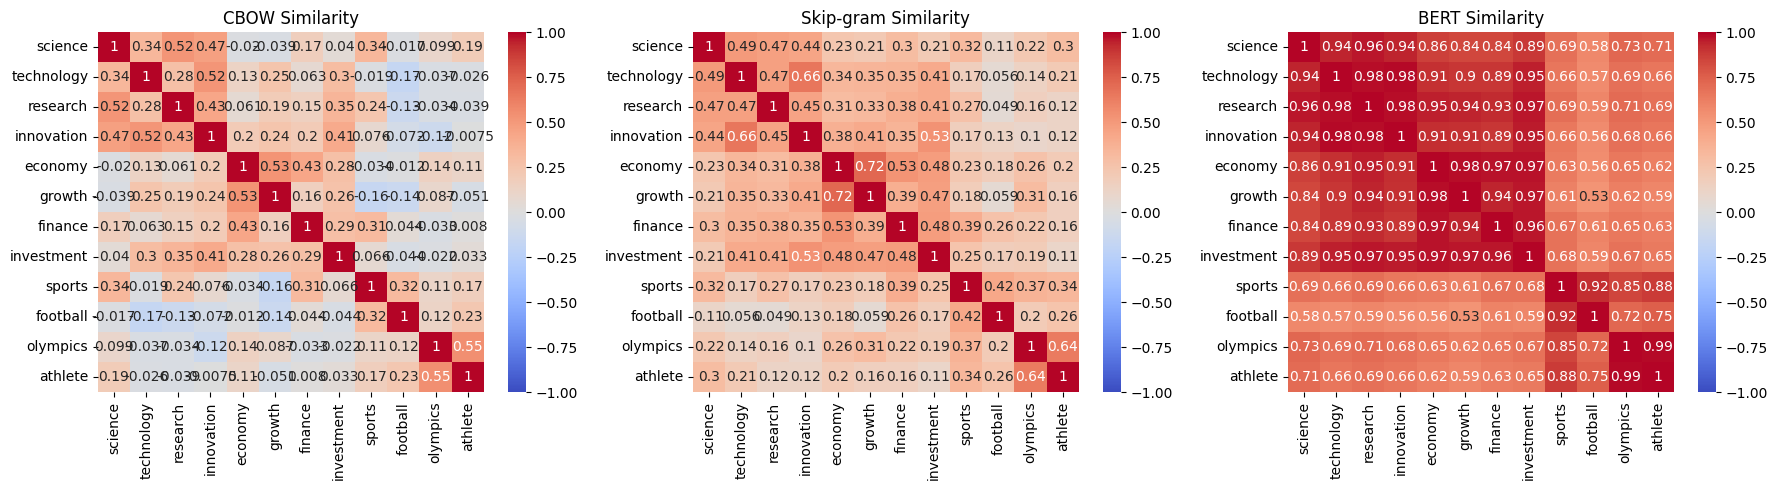

In [61]:
# --- Selected words ---
words = ['science', 'technology', 'research', 'innovation',
         'economy', 'growth', 'finance', 'investment',
         'sports', 'football', 'olympics', 'athlete']

# --- Helper to get Word2Vec vector ---
def get_w2v_vector(model, word):
    return model.wv[word] if word in model.wv else None

# --- Compute similarity matrix for Word2Vec ---
def compute_w2v_similarity(model):
    size = len(words)
    sim_matrix = np.zeros((size, size))
    for i, w1 in enumerate(words):
        v1 = get_w2v_vector(model, w1)
        for j, w2 in enumerate(words):
            v2 = get_w2v_vector(model, w2)
            if v1 is not None and v2 is not None:
                sim_matrix[i, j] = cosine_similarity([v1], [v2])[0][0]
            else:
                sim_matrix[i, j] = np.nan
    return pd.DataFrame(sim_matrix, index=words, columns=words)

# --- Compute similarity matrix for BERT ---
def compute_bert_similarity(bert_embeddings, corpus):
    size = len(words)
    sim_matrix = np.zeros((size, size))
    for i, w1 in enumerate(words):
        idx1 = [i for i, tokens in enumerate(corpus) if w1 in tokens]
        if not idx1:
            sim_matrix[i, :] = np.nan
            continue
        emb1 = np.mean(bert_embeddings[idx1], axis=0, keepdims=True)
        for j, w2 in enumerate(words):
            idx2 = [i for i, tokens in enumerate(corpus) if w2 in tokens]
            if not idx2:
                sim_matrix[i, j] = np.nan
            else:
                emb2 = np.mean(bert_embeddings[idx2], axis=0, keepdims=True)
                sim_matrix[i, j] = cosine_similarity(emb1, emb2)[0][0]
    return pd.DataFrame(sim_matrix, index=words, columns=words)

# --- Compute similarity matrices ---
cbow_sim = compute_w2v_similarity(model_cbow)
skip_sim = compute_w2v_similarity(model_skipgram)
bert_sim = compute_bert_similarity(bert_embeddings, corpus)

# --- Plot heatmaps ---
plt.figure(figsize=(18, 5))
plt.subplot(1,3,1)
sns.heatmap(cbow_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("CBOW Similarity")

plt.subplot(1,3,2)
sns.heatmap(skip_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Skip-gram Similarity")

plt.subplot(1,3,3)
sns.heatmap(bert_sim, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("BERT Similarity")

plt.tight_layout()
plt.show()


## Conclusion

**Comparison of Embedding Models: CBOW vs Skip-gram vs BERT**

- **CBOW**: Efficient for frequent words; captures general context but may miss subtle relationships in rare words.  
- **Skip-gram**: Better for rare words and capturing nuanced semantic relationships; slightly higher similarity scores for domain-specific terms.  
- **BERT**: Context-aware embeddings; captures nuanced meanings by considering surrounding text; better for sentence-level and context-sensitive tasks.  

**Insights:**

- CBOW and Skip-gram are lightweight and fast for word-level embeddings.  
- BERT is more computationally intensive but provides richer, context-sensitive representations.  

**Recommendation:**

- Use **Word2Vec** (CBOW/Skip-gram) for quick similarity and classical NLP tasks.  
- Use **BERT** when understanding context or sentence semantics is critical.
